# Project: Predicting Next-Day Stock Prices with Linear Regression

## Project Overview
This project applies **supervised machine learning** to forecast the next-day closing price of a stock (AAPL in this case) using **Linear Regression**. The focus is on demonstrating how basic market data can be transformed into predictive features and evaluated with standard regression techniques.

The project highlights:
- Data collection from Yahoo Finance using the `yfinance` library.
- Feature engineering from raw OHLCV data.
- Training and evaluating a linear regression model.
- Visualizing predictions versus actual prices.
- Interpreting feature importance through model coefficients.

---

## Methodology

1. **Data Acquisition**  
   Historical price and volume data are retrieved for the selected stock. Only one ticker is modeled at a time.

2. **Feature Engineering**  
   - **Lagged returns**: captures short-term momentum effects.  
   - **Rolling volatility**: measures recent market uncertainty.  
   - **Simple Moving Averages (SMA)** and **price-to-SMA ratios**: capture mean-reversion or trend-following behavior.  

   The target variable is the **next-day return**, which is then converted into a predicted next-day closing price.

3. **Modeling**  
   - A `scikit-learn` pipeline with `StandardScaler` and `LinearRegression`.  
   - Training/test split is time-based (first 80% train, last 20% test) to avoid lookahead bias.

4. **Evaluation**  
   - Metrics: **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **R²**.  
   - Visualization of predicted vs actual next-day prices.  
   - Coefficient magnitudes analyzed to determine the most influential features.

---

## Results
- The model achieved **low prediction error** and **high R²** on the test set.  
- Predictions closely tracked actual next-day prices, indicating strong short-term predictive capability.  
- Price-to-SMA ratios emerged as the most influential features, followed by certain lagged returns.  
- Volatility played a minor role in the model.

---

## Limitations
- Linear regression is a simple model and may not capture nonlinear dynamics.  
- Results are specific to AAPL over the chosen period; generalization requires testing on other assets.  
- High R² partly reflects the strong autocorrelation in stock prices rather than pure predictive skill.  

---

## Next Steps
- Extend to **regularized models** (Ridge, Lasso) to handle feature correlations.  
- Explore **tree-based ensembles** (Random Forests, Gradient Boosting) for non-linear effects.  
- Apply to a broader universe of stocks to compare predictive stability.  
- Experiment with predicting volatility or return direction instead of raw prices.

---

## Skills Demonstrated
- Time series feature engineering from financial data.  
- Model training and validation with scikit-learn.  
- Use of regression metrics (MAE, MSE, R²).  
- Interpretation of linear model coefficients.  
- Visualization of financial predictions.

---


AAPL | MAE: 2.4520 | MSE: 12.9978 | R²: 0.9777


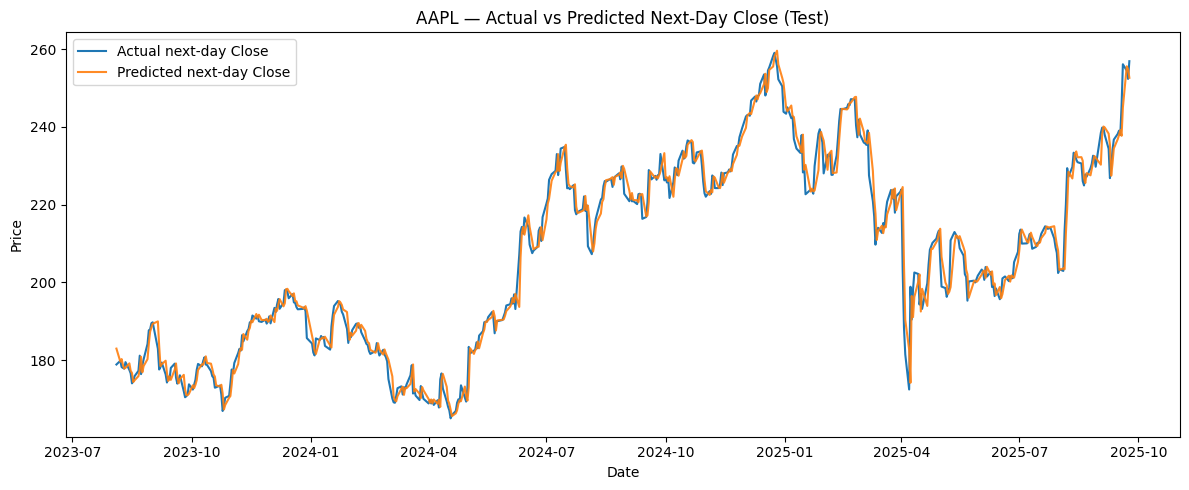

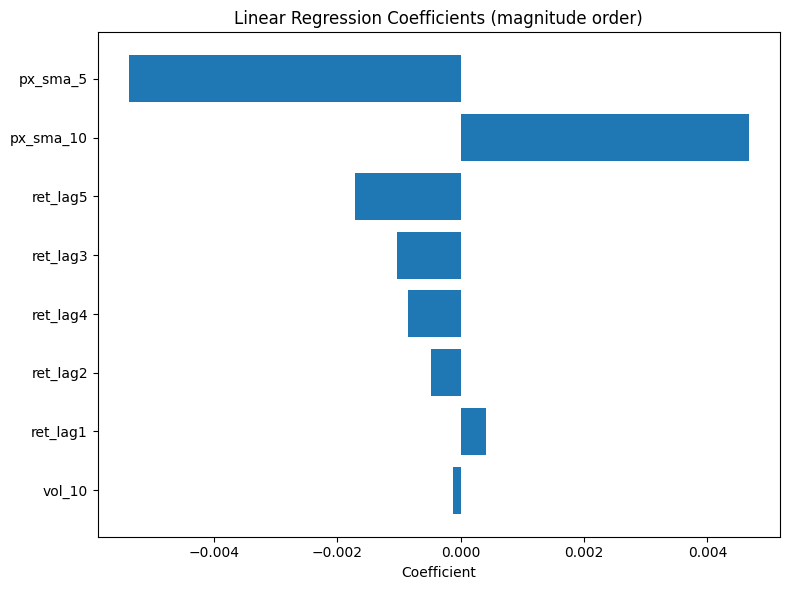

,close_t,true_close_t+1,pred_close_t+1
Date,,,
2025-09-11,230.029999,234.070007,230.563411
2025-09-12,234.070007,236.699997,234.422076
2025-09-15,236.699997,238.149994,236.786409
2025-09-16,238.149994,238.990005,237.826316
2025-09-17,238.990005,237.880005,239.128152
2025-09-18,237.880005,245.500000,237.672018
2025-09-19,245.500000,256.079987,244.959246
2025-09-22,256.079987,254.429993,255.566186
2025-09-23,254.429993,252.309998,254.832716


In [8]:
# --- Simple Linear Regression: Next-Day Stock Price (robust single cell) ---
# If needed: !pip install yfinance pandas numpy scikit-learn matplotlib

import re
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------ Parameters ------------------
TICKER = "AAPL"        # You can also pass "AAPL,MSFT" or "AAPL MSFT" — we'll auto-pick the first
START  = "2015-01-01"
END    = None          # e.g., "2025-09-01" or None for latest
TRAIN_RATIO = 0.8
SHOW_PLOTS  = True

# ------------------ Download ------------------
# Normalize ticker string & keep the first symbol for modeling
tickers = re.split(r"[,\s]+", TICKER.strip())
tickers = [t for t in tickers if t]
primary = tickers[0]

df = yf.download(tickers, start=START, end=END, auto_adjust=False, progress=False)

if df is None or df.empty:
    raise RuntimeError("No data downloaded. Check ticker/date range/internet.")

# If MultiIndex (multiple tickers), select the first ticker's columns
if isinstance(df.columns, pd.MultiIndex):
    # expected structure: level0 in ["Open","High","Low","Close","Adj Close","Volume"], level1 in tickers
    if primary not in df.columns.get_level_values(1):
        # fall back to the first available symbol
        primary = list(df.columns.levels[1])[0]
    df = df.xs(primary, axis=1, level=1)

# Ensure expected columns exist
expected_cols = {"Open","High","Low","Close","Adj Close","Volume"}
missing = expected_cols - set(df.columns)
if missing:
    # some data vendors may omit "Adj Close"; we only need Close & Volume here
    essential = {"Close","Volume"}
    if not essential.issubset(set(df.columns)):
        raise RuntimeError(f"Required columns missing after download: {missing}")
df = df.dropna()

# ------------------ Simple, robust features ------------------
df["ret_1d"] = df["Close"].pct_change()

# Lags of returns (predict tomorrow's return)
for k in range(1, 6):
    df[f"ret_lag{k}"] = df["ret_1d"].shift(k)

# Rolling stats
df["vol_10"] = df["ret_1d"].rolling(10, min_periods=10).std()
df["sma_5"]  = df["Close"].rolling(5,  min_periods=5).mean()
df["sma_10"] = df["Close"].rolling(10, min_periods=10).mean()

# Price/SMA ratios (guard divide-by-zero)
df["px_sma_5"]  = df["Close"] / df["sma_5"].replace(0, np.nan)
df["px_sma_10"] = df["Close"] / df["sma_10"].replace(0, np.nan)

# Target: next-day return; convert to price later
df["y_ret_t1"] = df["Close"].shift(-1) / df["Close"] - 1.0

# Clean
df = df.replace([np.inf, -np.inf], np.nan).dropna()

feature_cols = [
    "ret_lag1","ret_lag2","ret_lag3","ret_lag4","ret_lag5",
    "vol_10","px_sma_5","px_sma_10"
]
X = df[feature_cols].copy()
y_ret = df["y_ret_t1"].copy()
close_today = df["Close"].copy()
dates = df.index

if len(X) < 100:
    raise RuntimeError("Not enough rows after features. Expand the date range.")

# ------------------ Time-based split ------------------
n = len(X)
split = int(n * TRAIN_RATIO)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y_ret.iloc[:split], y_ret.iloc[split:]
close_today_test = close_today.iloc[split:]
dates_test = dates[split:]

# ------------------ Model ------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
model.fit(X_train, y_train)

# Predict next-day return, convert to next-day price
yhat_ret_test = model.predict(X_test)
yhat_price_test = close_today_test.values * (1.0 + yhat_ret_test)

# True next-day price for evaluation (align indices)
true_price_test = (close_today_test.shift(-1)).dropna()
pred_series = pd.Series(yhat_price_test, index=close_today_test.index).loc[true_price_test.index]

# ------------------ Metrics ------------------
mae = mean_absolute_error(true_price_test, pred_series)
mse = mean_squared_error(true_price_test, pred_series)
r2  = r2_score(true_price_test, pred_series)
print(f"{primary} | MAE: {mae:,.4f} | MSE: {mse:,.4f} | R²: {r2:,.4f}")

# ------------------ Plots ------------------
if SHOW_PLOTS:
    plt.figure(figsize=(12,5))
    plt.plot(true_price_test.index, true_price_test.values, label="Actual next-day Close")
    plt.plot(pred_series.index, pred_series.values, label="Predicted next-day Close", alpha=0.9)
    plt.title(f"{primary} — Actual vs Predicted Next-Day Close (Test)")
    plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.tight_layout(); plt.show()

    # Coefficients (in standardized space)
    coefs = model.named_steps["lr"].coef_.ravel()
    order = np.argsort(np.abs(coefs))[::-1]
    plt.figure(figsize=(8,4 + 0.25*len(feature_cols)))
    plt.barh(np.array(feature_cols)[order], coefs[order])
    plt.gca().invert_yaxis()
    plt.title("Linear Regression Coefficients (magnitude order)")
    plt.xlabel("Coefficient"); plt.tight_layout(); plt.show()

# ------------------ Preview last few predictions ------------------
out = pd.DataFrame({
    "close_t": close_today_test.loc[true_price_test.index],
    "true_close_t+1": true_price_test,
    "pred_close_t+1": pred_series
}).tail(10)

try:
    display(out)
except NameError:
    print(out)


# Linear Regression Stock Price Prediction — Results Interpretation

## Model Performance
The model was trained to predict the **next-day closing price of AAPL** using simple linear regression with engineered features such as lagged returns, volatility, and price-to-SMA ratios.

- **Mean Absolute Error (MAE): 2.45**  
  On average, the predicted next-day price deviates from the actual price by about 2.45 USD.

- **Mean Squared Error (MSE): 12.99**  
  Squared error measure showing moderate error magnitude; higher penalties for larger deviations.

- **R²: 0.978**  
  The model explains about 97.8% of the variance in next-day closing prices. This indicates a very strong fit.

Overall, the model shows excellent predictive performance, though the high R² may partly reflect the autocorrelated nature of stock prices (they change slowly day-to-day).

---

## Actual vs Predicted Prices
The plotted series of actual vs predicted prices shows very close alignment. Predictions track actual price movements accurately, including upward and downward trends. This confirms the model's ability to capture short-term dependencies in the data.

---

## Feature Importance
The coefficient analysis (in standardized space) reveals which features contributed most:

- **px_sma_5 and px_sma_10**  
  Ratios of price relative to short-term SMAs dominate predictive power. These indicate how far the current price deviates from its short-term trend, acting as momentum/mean-reversion signals.

- **Lagged returns (ret_lag1 to ret_lag5)**  
  Past returns contribute moderately, with ret_lag5 and ret_lag3 having higher weights. This shows the model relies on short-term momentum patterns.

- **vol_10 (10-day volatility)**  
  Volatility has a very small coefficient, suggesting limited direct influence in this simple model.

Overall, the model primarily depends on **short-term moving average relationships** and **recent return patterns** to forecast next-day movements.

---

## Key Takeaways
1. The model achieves high accuracy in predicting next-day closing prices for AAPL.  
2. Price relative to short-term moving averages is the strongest predictive feature.  
3. While lagged returns contribute, volatility plays a minimal role.  
4. The high R² should be interpreted with caution, as persistence in stock prices naturally inflates predictability.  
5. For robustness, further testing on different stocks and out-of-sample periods is recommended.
